## Assignment Task: Path Interpolation and Visualization

In this exercise, you are provided with a CSV file named `loop_track_waypoints.csv`, which contains a sequence of indexed 2D waypoints that form a closed-loop track. Your task is to interpolate these waypoints to generate a smooth continuous path and visualize the resulting curve.

### Dataset Description

The CSV file contains the following columns:

- `Index`: An integer representing the order of the waypoint.
- `x`: The x-coordinate of the waypoint (in meters).
- `y`: The y-coordinate of the waypoint (in meters).

The track is closed, i.e., the final waypoint coincides with the starting point to form a loop.

### Objectives

1. **Read** the CSV file using an appropriate data processing library such as `pandas`.
2. **Perform interpolation** over the waypoints using a method of your choice (e.g., `scipy.interpolate` or spline interpolation).
3. **Visualize** both the original discrete waypoints and the resulting smooth curve on the same plot for comparison.
4. Ensure the interpolated path **preserves the closed-loop nature** of the track.

### Recommended Libraries

You may use the following libraries:
- `pandas` for reading the CSV file.
- `matplotlib` or `plotly` for visualization.
- `scipy.interpolate` (e.g., `splprep` and `splev`) or `interp1d` for interpolation.

### 📌 Instructions

- Ensure that the file `loop_track_waypoints.csv` is placed in the **same directory** as this notebook.
- Label your axes and add a legend to your plot.
- Comment your code appropriately to explain the logic and steps used.
- Try using both linear and spline-based interpolation methods if time permits.


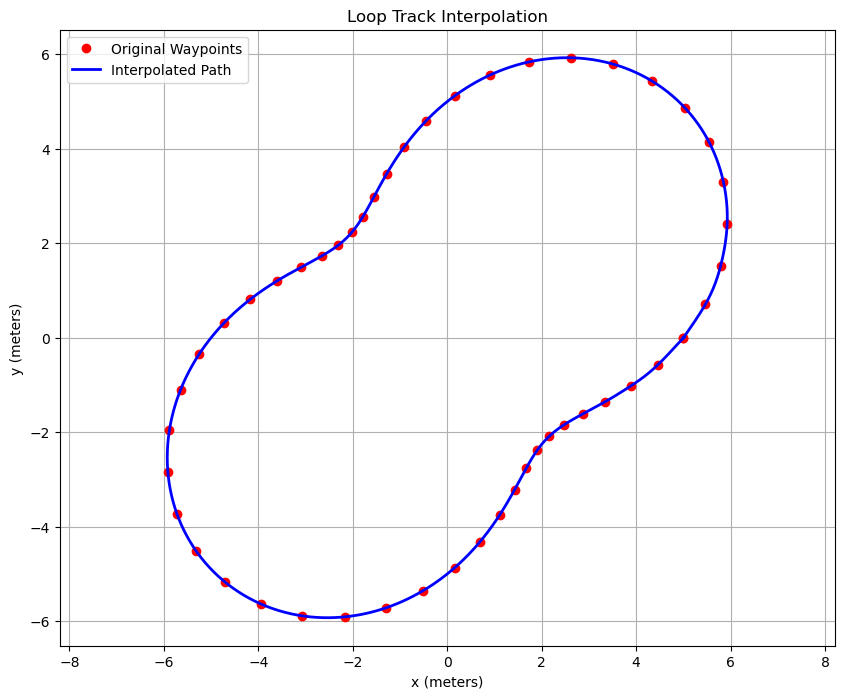

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev

# 1. Read the CSV file
df = pd.read_csv('loop_track_waypoints.csv')

# Extract x and y coordinates
x = df['X'].values
y = df['Y'].values

# 2. Prepare for closed-loop interpolation
# For closed loop, we need to append the first point to the end
x_closed = np.append(x, x[0])
y_closed = np.append(y, y[0])

# 3. Parameterize the curve (t represents the "time" along the curve)
t = np.linspace(0, 1, len(x_closed))

# 4. Perform cubic spline interpolation
# s=0 means no smoothing - exact interpolation
tck, u = splprep([x_closed, y_closed], u=t, s=0, per=True)  # per=True for periodic (closed loop)

# 5. Create finer interpolation for smooth curve
u_new = np.linspace(0, 1, 1000)  # 1000 points for smooth curve
x_new, y_new = splev(u_new, tck)

# 6. Visualization
plt.figure(figsize=(10, 8))

# Plot original waypoints
plt.plot(x, y, 'ro', label='Original Waypoints', markersize=6)

# Plot interpolated curve
plt.plot(x_new, y_new, 'b-', label='Interpolated Path', linewidth=2)

# Add labels and title
plt.xlabel('x (meters)')
plt.ylabel('y (meters)')
plt.title('Loop Track Interpolation')
plt.legend()
plt.grid(True)
plt.axis('equal')  # Ensure equal scaling for x and y axes
plt.show()